In [167]:
from statistics import correlation

import h5py
import matplotlib.pyplot as plt
import numpy as np
import os

from maui_analysis.process_behavior import pull_fictrac_speed, pull_fictrac_timestamps, save_speed_data
from maui_analysis.data_alignment import *
from maui_codebook.visualizations import *
import xarray as xr
import glob
import scipy.cluster.hierarchy as shc
from scipy.interpolate import interp1d

In [168]:
# functions
def interpolate_walking_speeds(walk_times, walk_speeds, maui_vol_timestamps):
    f = interp1d(walk_times, walk_speeds)
    speed_new = f(maui_vol_timestamps)
    return speed_new

def plot_zscored_activity(clusters_toplot, signal_xarray, yshift = 1):
    fig, ax = plt.subplots(nrows=2,ncols=1, figsize=(20, len(clusters_toplot)))
    # yshift = 1
    # n_lines = len(clusters_toplot)
    palette_colors = sns.color_palette("Blues", len(clusters_toplot))

    for idx, ind_cluster in enumerate(clusters_toplot):
        to_plot = signal_xarray.isel(zposs=ind_cluster[0], roi=ind_cluster[1])
        ax.plot(signal_xarray.coords["time"], to_plot + (yshift * idx), color="b")

import matplotlib.colors as colors
def plot_spatial_location(clusters_toplot, cluster_2d_arr, brain_dimensions):
    fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(40, 40), constrained_layout=True)
    palette_colors = sns.color_palette("twilight", 25)
    cmap = ListedColormap(palette_colors)

    axes = axes.flatten()
    blank_brain = create_blank_brain(cluster_2d_arr)
    for cluster in clusters_toplot:
        identify_single_cluster(cluster_2d_arr, blank_brain, cluster)

    blank_brain_clusters = blank_brain.reshape(brain_dimensions[2], brain_dimensions[0], brain_dimensions[1])
    raw_brain_clusters = cluster_2d_arr.reshape(brain_dimensions[2], brain_dimensions[0], brain_dimensions[1])

    for idx in range(brain_dimensions[2]):
        ax = axes[idx]
        # ax.imshow(raw_brain_clusters[idx].T, cmap="gray_r", alpha=0.7)
        ax.imshow(blank_brain_clusters[idx].T, cmap=cmap, alpha=1)
        ax.set_title(f"Slice {idx}")

    for j in range(brain_dimensions[2], len(axes)):
        fig.delaxes(axes[j])

In [339]:
experiment_list = glob.glob('/Volumes/AhmedLab/princess/data/pIP10/processed/*')
print(experiment_list[:-6])

['/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260421_GC8m_fly02_win01_trial0-001', '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260421_GC8m_fly02_win03_trial0-001', '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260421_GC8m_fly03_win01_trial-001', '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260421_GC8m_fly03_win02_trial-001', '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260425_GC8m_fly04_win01_trial-001', '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260425_GC8m_fly04_win02_trial-001', '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260425_GC8m_fly05_win01_trial-001', '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260427_GC8m_fly09_win01_trial-001', '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260427_GC8m_fly09_win02_trial-001', '/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_20260427_GC8m_fly09_win03

In [326]:
# choose fly
fly = '04'
win = '1'
# check for signal and shifted signals
file = glob.glob(f'/Volumes/AhmedLab/princess/data/pIP10/processed/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/20_supervoxels.h5')[0]
with h5py.File(file, "r") as f:
    print(f.keys())
# set dimensions
DIMENSIONS = [512, 512, 11]
SLICES = DIMENSIONS[2]
BASE_DIRECTORY = '/Volumes/AhmedLab/princess/data/pIP10/'
RAW_DIR = f'{BASE_DIRECTORY}/raw/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/'
PROCESSED_DIR = f'{BASE_DIRECTORY}/processed/pIP10_TSeries_*_GC8m_fly{fly}_win0{win}_trial*-001/'

<KeysViewHDF5 ['labels', 'shifted_signals']>


In [333]:
x = False or True
print(x)

True


In [234]:
# load all files
with h5py.File(file, "r") as f:
    print(f.keys())
    cluster_labels = f["labels"][...]
    signal = f["signals"][...]
    shift = f["shifted_signals"][...]

voltage_csv = glob.glob(f'{RAW_DIR}/*VoltageRecording_001.csv')[0]
dat_file = glob.glob(f'{PROCESSED_DIR}*.dat')[0]
synchronized_hf = f'{PROCESSED_DIR}/synced_data.h5'
if not glob.glob(synchronized_hf):
    save_path = glob.glob(os.path.dirname(synchronized_hf))[0]
    save_speed_data(dat_file, voltage_csv, save_path=save_path)
    # # takes ~2-3 minutes
synced_data_hf = glob.glob(synchronized_hf)[0]
with h5py.File(synced_data_hf, "r") as f:
    print(f.keys())
# align to scope data
maui_vol_timestamps = align_scopetimes_to_behaviortimes(RAW_DIR, synced_data_hf, SLICES)
walk_times, walk_speeds = open_processed_behavior_data(synced_data_hf)
print(len(walk_times), len(walk_speeds))
synced_walk_speeds = interpolate_walking_speeds(walk_times, walk_speeds, maui_vol_timestamps)

signal = signal[...,:len(maui_vol_timestamps)]
shift = shift[...,:len(maui_vol_timestamps)]

<KeysViewHDF5 ['labels', 'shifted_signals', 'signals']>
<KeysViewHDF5 ['behavior timestamps', 'fly speed']>
<KeysViewHDF5 ['behavior timestamps', 'fly speed']>
<KeysViewHDF5 ['behavior timestamps', 'fly speed']>
156791 156791


In [235]:
# format into x arrays
signal_xr = xr.DataArray(
    data=signal,
    dims=['zposs', 'roi', 'time'],
    coords={'time': maui_vol_timestamps/1000}
)
sh_signal_xr = xr.DataArray(
    data=shift,
    dims=['zposs', 'roi', 'time'],
    coords={'time': maui_vol_timestamps/1000}
)

behav_xr = xr.DataArray(
    data = synced_walk_speeds,
    dims = ['time'],
    coords = {'time': maui_vol_timestamps/1000}
)

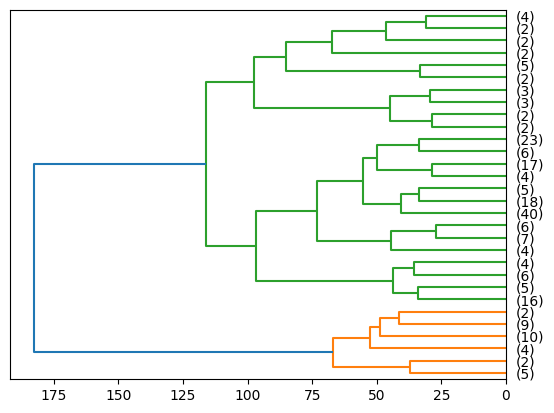

In [240]:
# CLUSTER SUPERVOXELS BY ACTIVITY OVER TIME

# cluster signal across all supervoxels by time
NCLUSTERS = 30

supervox_signal = signal_xr.stack(supervoxel=['zposs', 'roi']).T
Z = shc.linkage(supervox_signal, method='ward')
_ = shc.dendrogram(Z, orientation='left', truncate_mode='lastp', p=NCLUSTERS)
clust_labels = shc.fcluster(Z, NCLUSTERS, criterion='maxclust')

# add cluster id as new coordinate
# each supervoxel now has a designated cluster id
# adds in the cluster number as a new coordinate - each supervoxel has a designated cluster
grouped_sv = supervox_signal.assign_coords(cluster = ('supervoxel', clust_labels)).set_index(supervoxel='cluster', append=True)

(11, 262144)


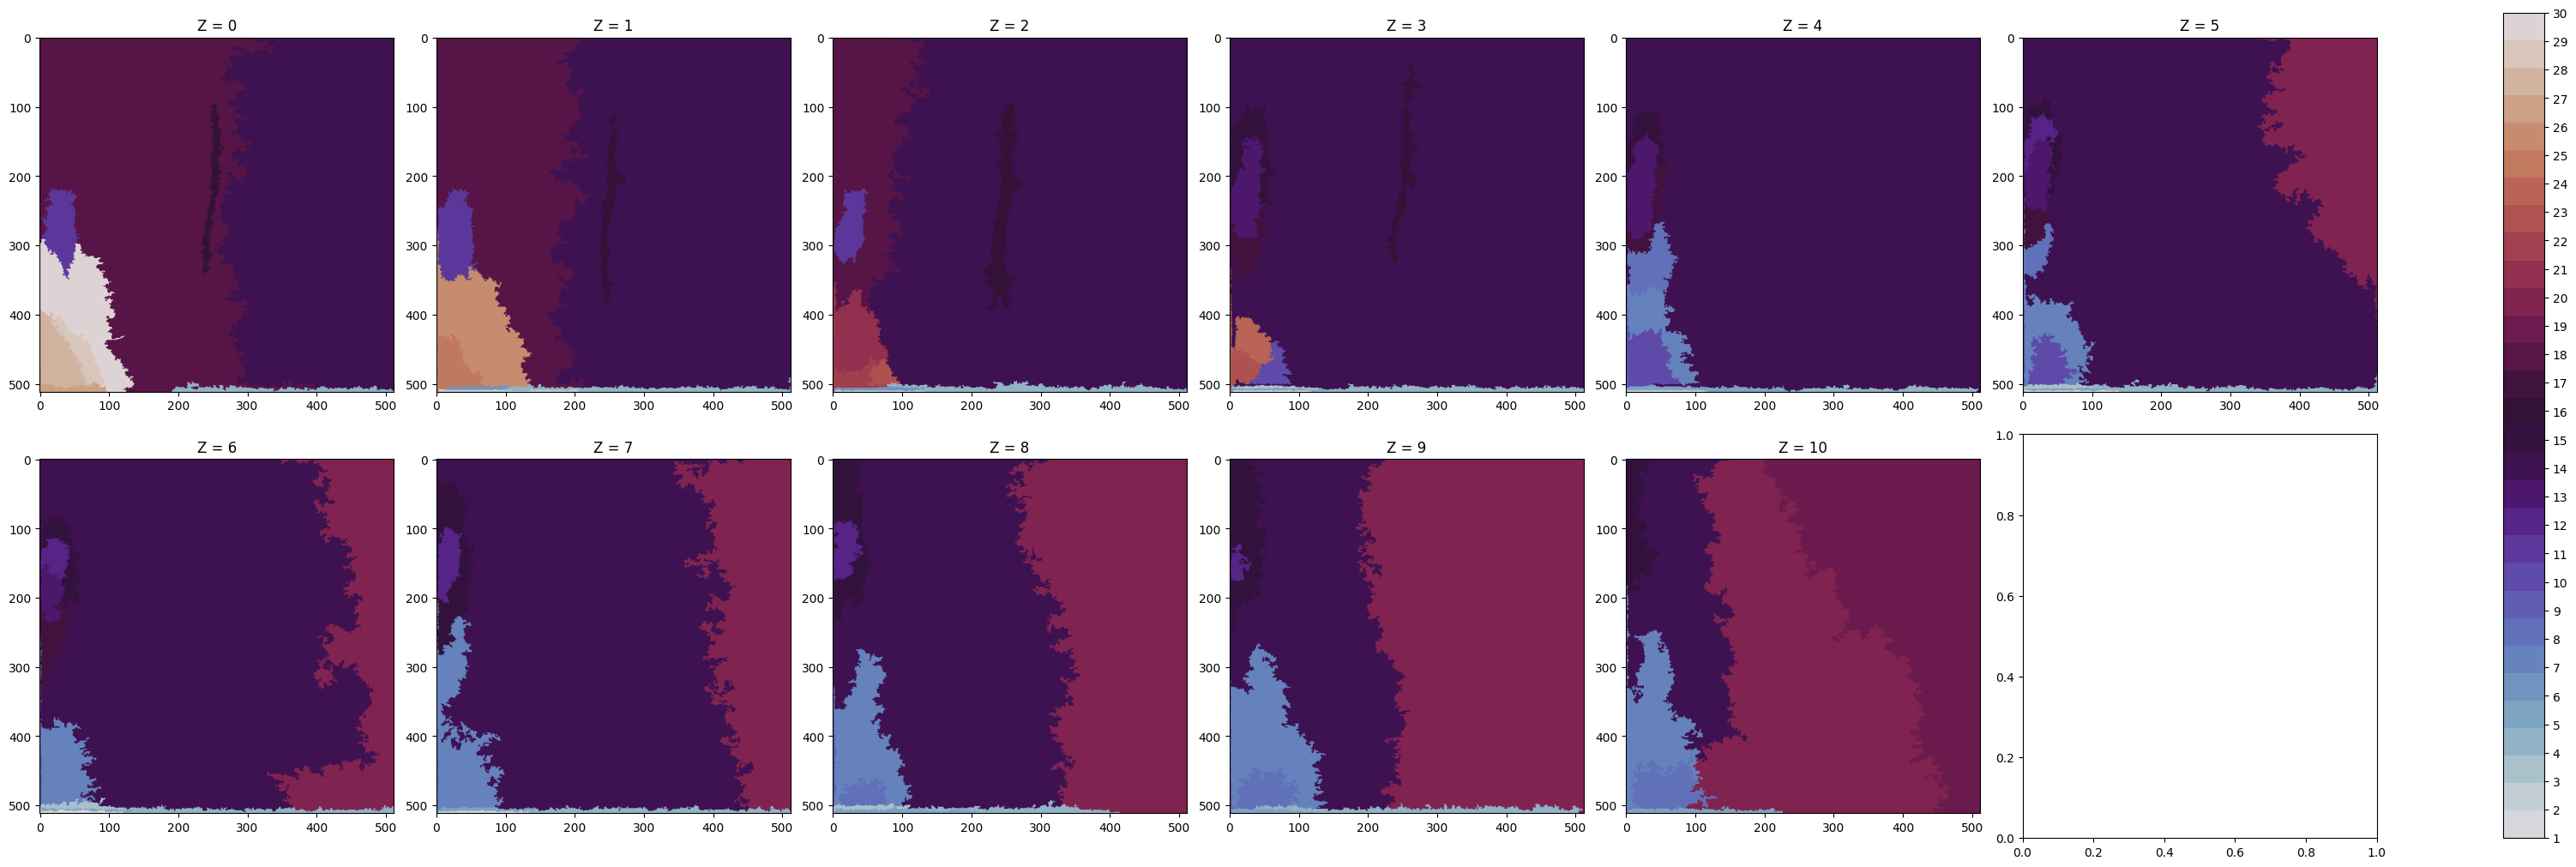

In [241]:
# color spatial maps by cluster id
clusters_spatial = np.empty(cluster_labels.shape, dtype=int)
print(clusters_spatial.shape)
for z,px_list in enumerate(cluster_labels):
    # find cluster value
    values = grouped_sv.supervoxel.sel(zposs=z).cluster.values
    for px, sv in enumerate(px_list):
        clusters_spatial[z,px] = values[sv]

norm = colors.Normalize(vmin=1, vmax=NCLUSTERS)
palette_colors = sns.color_palette("twilight", NCLUSTERS)
cmap = ListedColormap(palette_colors)
#
fig, axes = plt.subplots(nrows=2, ncols=6, figsize=(30, 10), constrained_layout=True)
axes = axes.flatten()
for z in range(SLICES):
    ax = axes[z]
    image = np.reshape(clusters_spatial[z],[512,512])
    map = ax.imshow(image.T, cmap=cmap, norm=norm)
    ax.set_title(f'Z = {z}')
plt.colorbar(map, ax=axes.ravel(),ticks=np.arange(1,NCLUSTERS+1))

In [243]:
# select pIP10 supervoxels
# print all supervoxels in one cluster, in specific slices
supervoxel_subset = []
COOL_CLUSTER = 16
for z in range(0, 5): # slice range
    values = grouped_sv.supervoxel.sel(zposs=z).cluster.values
    for idx, v in enumerate(values):
        if v == COOL_CLUSTER:
            supervoxel_subset.append([z,idx])
print(supervoxel_subset)
print(len(supervoxel_subset))

[[0, 16], [1, 8], [2, 13], [2, 19], [3, 10]]
5


5


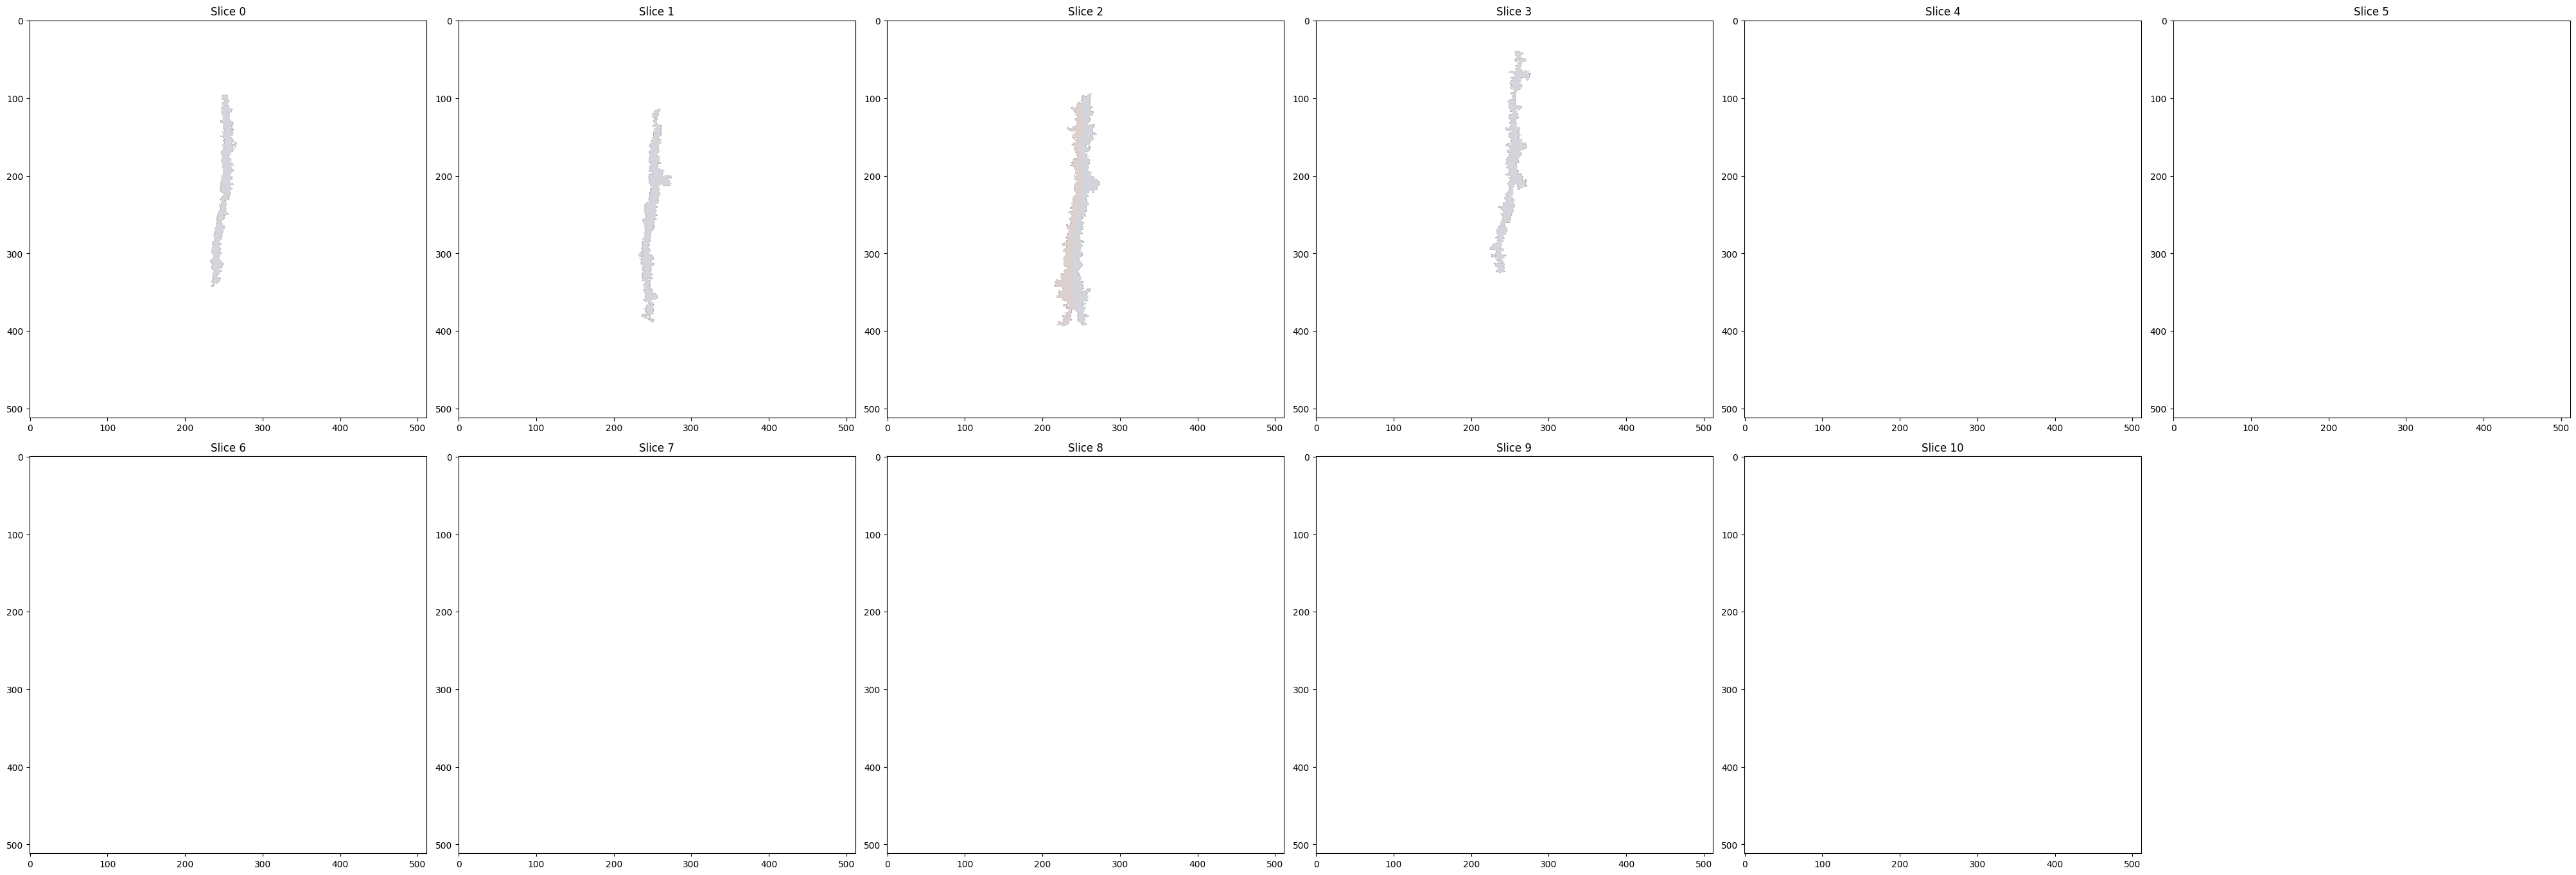

In [245]:
indexs = [0, 1,2, 3, 4, ]
pip_rois = [supervoxel_subset[x] for x in indexs]
print(len(pip_rois))
plot_spatial_location(pip_rois, cluster_labels, DIMENSIONS)

In [250]:
def plot_zscored_activity(clusters_toplot, signal_xarray, yshift = 1, title = None):
    # fig, axes = plt.subplots(ncols=1,nrows=2, figsize=(20, len(clusters_toplot)), gridspec_kw={'width_ratios': [3, 1]})
    fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(20, 15),
    gridspec_kw={'height_ratios': [3, 1]}
)
    fig.tight_layout()
    # palette_colors = sns.color_palette("Blues", len(clusters_toplot))
    # axes = axes.flatten()

    for idx, ind_cluster in enumerate(clusters_toplot):
        to_plot = signal_xarray.isel(zposs=ind_cluster[0], roi=ind_cluster[1])
        ax1.plot(signal_xarray.coords["time"], to_plot + (yshift * idx), color="b")
        if title is not None:
            ax1.set_title(f'{title}')

    ax2.plot(synced_walk_speeds)
    ax2.set_title('walking speed')

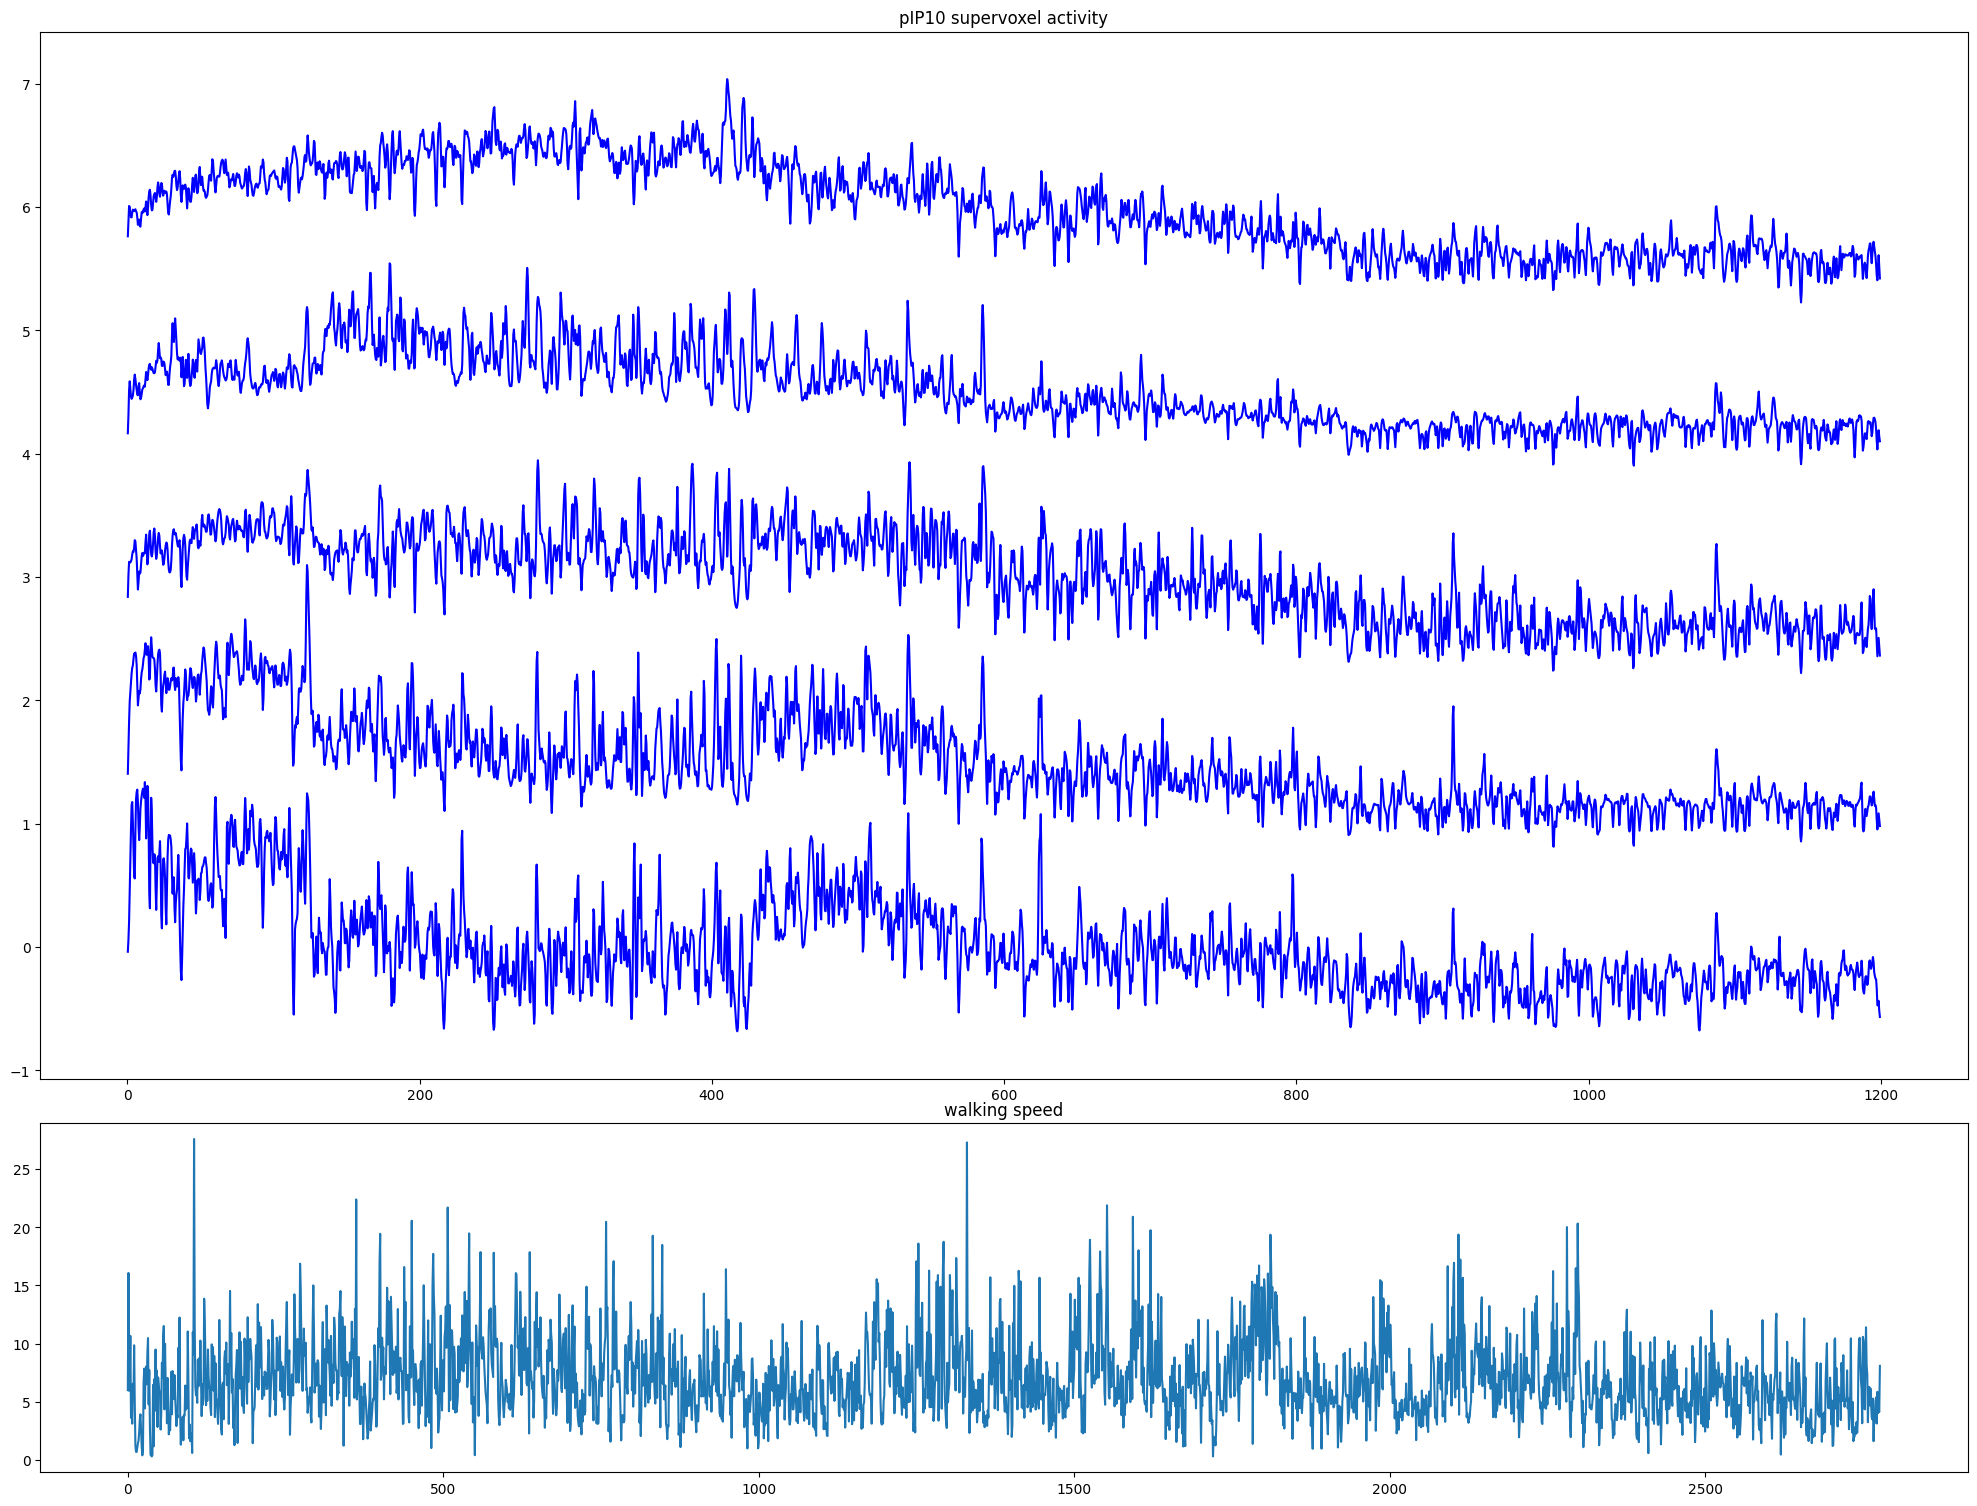

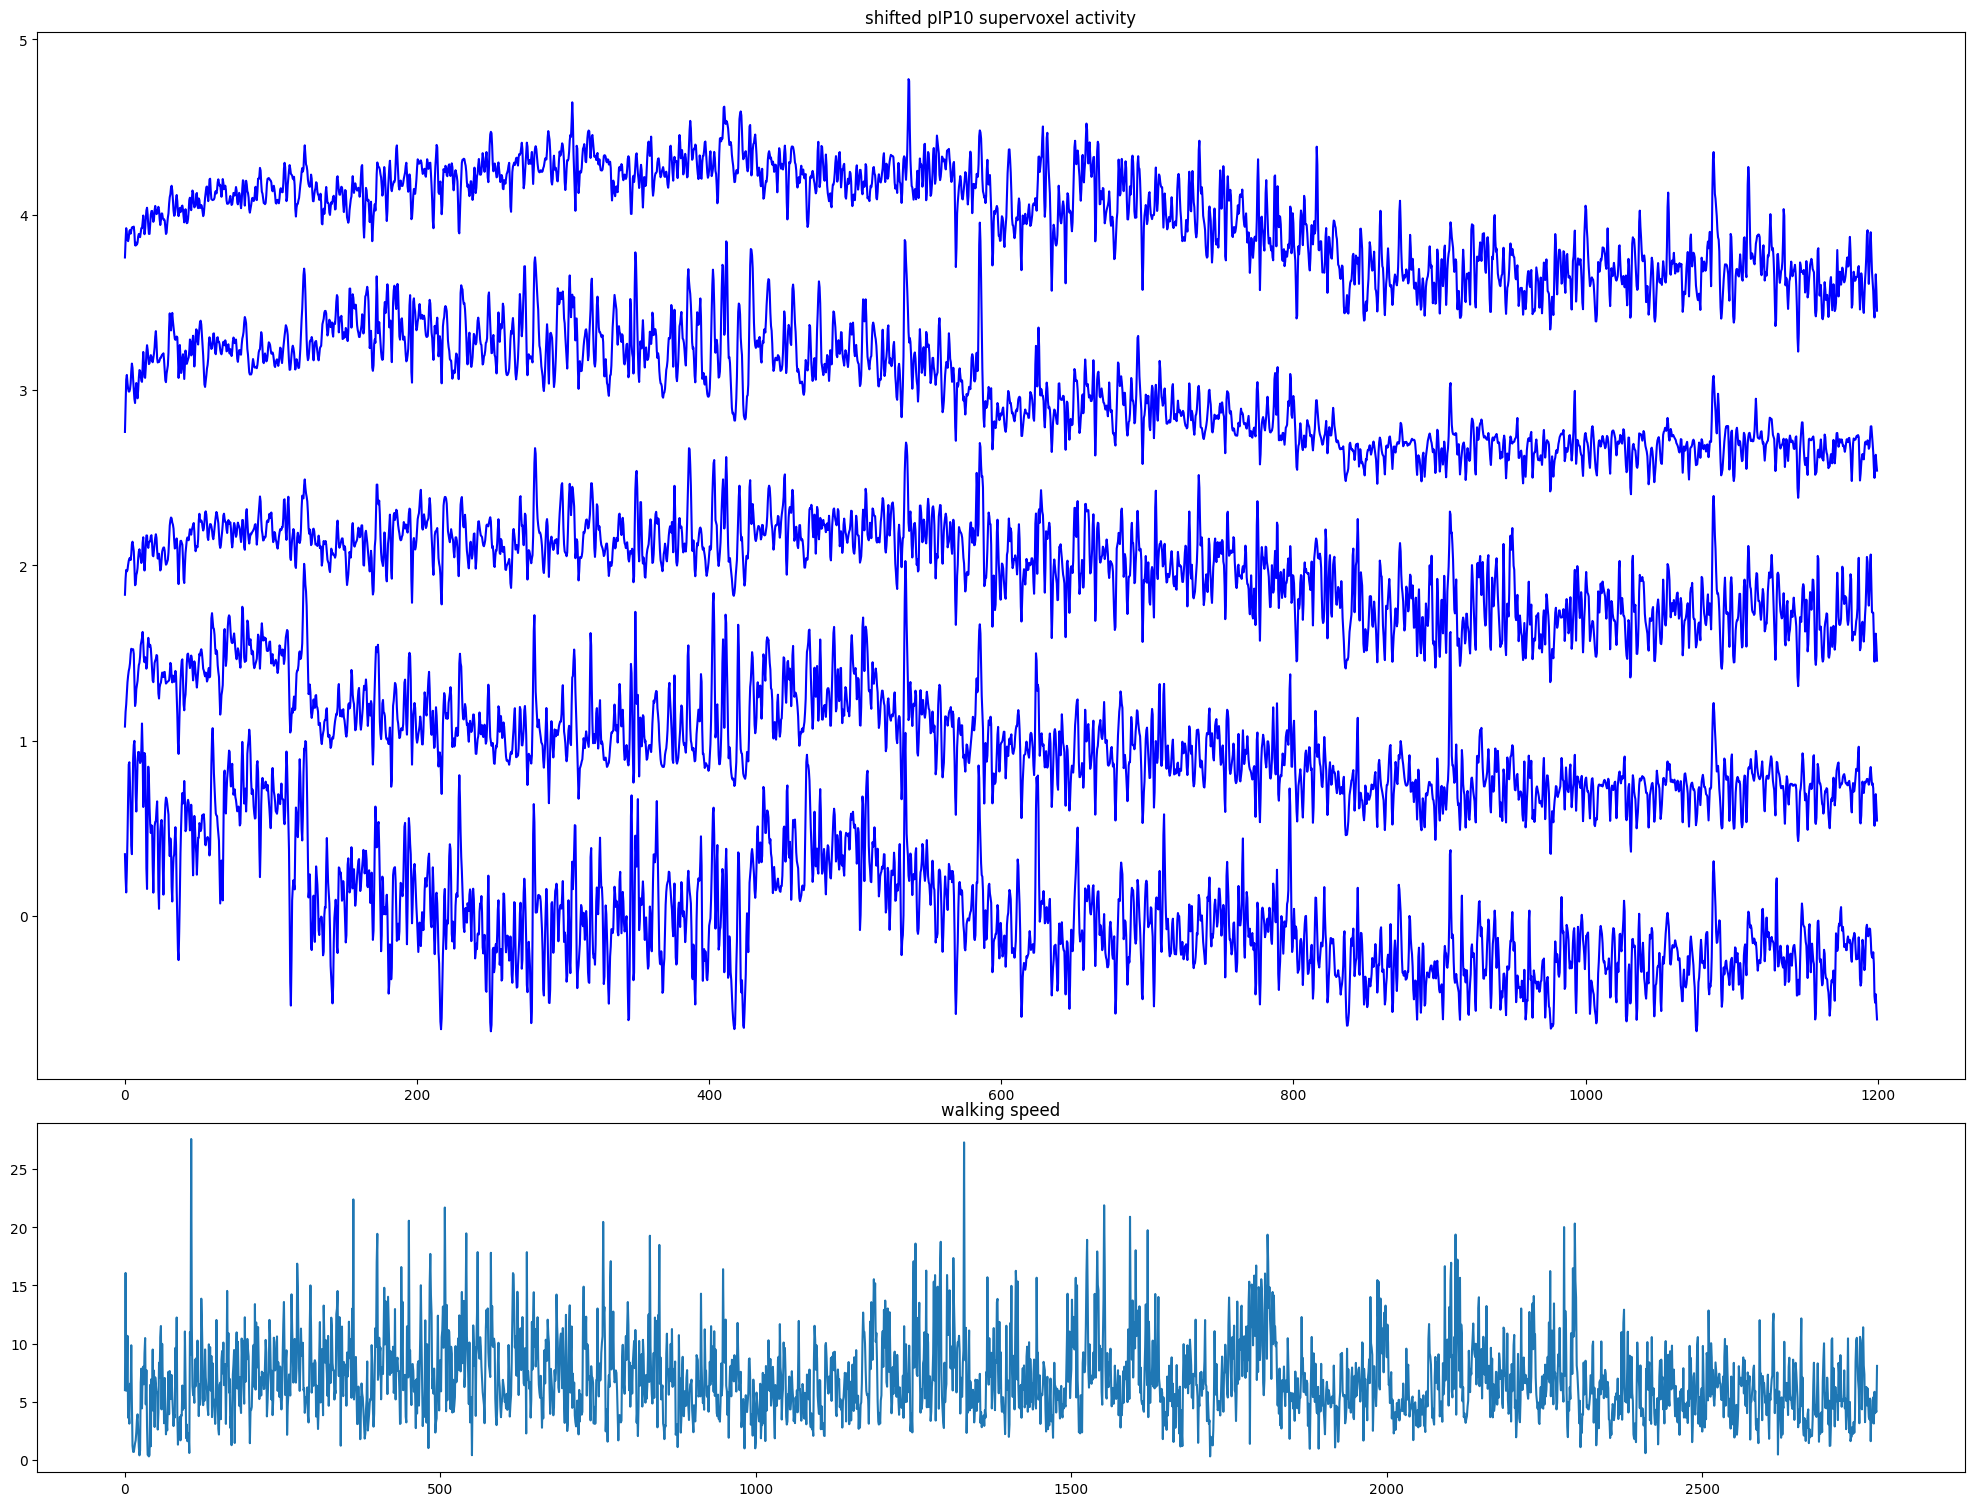

In [252]:
plot_zscored_activity(pip_rois, signal_xr, yshift=1.5, title = 'pIP10 supervoxel activity')
plot_zscored_activity(pip_rois, sh_signal_xr, title = 'shifted pIP10 supervoxel activity')

In [248]:
len(signal_xr.coords['time'])
print(signal_xr.coords['time'].values[700])

302.508070909091


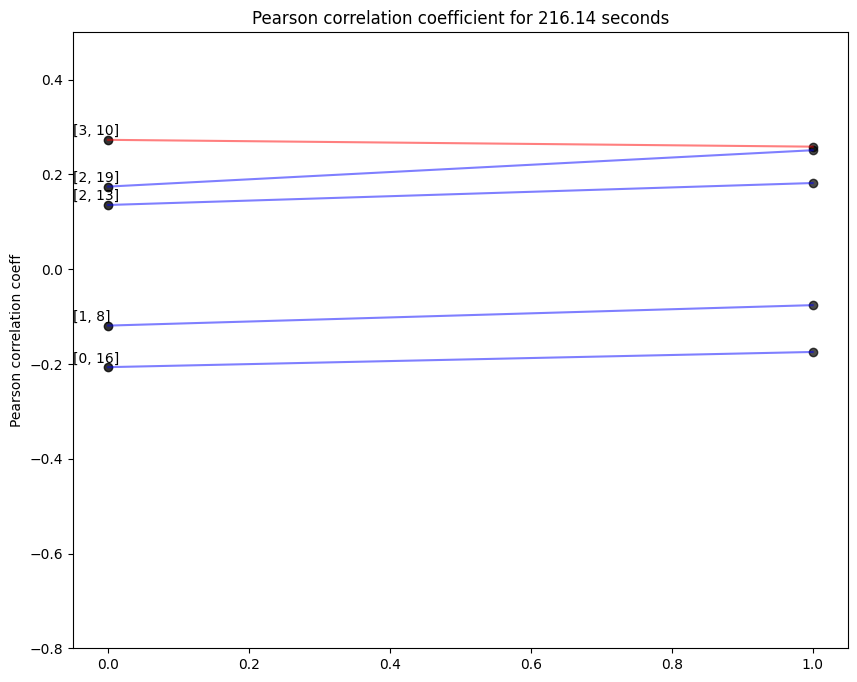

In [300]:
# truncate xarrays
total_length = signal_xr.coords['time'].size
DRIFT_INDEX = 500

trunc_signal = signal_xr.isel(time=slice(0, DRIFT_INDEX))
trunc_sh_signal = sh_signal_xr.isel(time=slice(0, DRIFT_INDEX))
trunc_behavior = behav_xr.isel(time=slice(0, DRIFT_INDEX))

# run correlation to walk
correlation = xr.corr(trunc_signal, trunc_behavior, dim='time')
sh_correlation = xr.corr(trunc_sh_signal, trunc_behavior, dim='time')

plt.figure(figsize=(10, 8))
plt.tight_layout()
for pip in pip_rois:
    to_plot = correlation.isel(zposs=pip[0], roi=pip[1])
    to_plot_sh = sh_correlation.isel(zposs=pip[0], roi=pip[1])

    if to_plot_sh < to_plot:
        color = 'red'
    else:
        color = 'blue'
    plt.plot([0,1], [to_plot, to_plot_sh], color=color, alpha=0.5, label= f'{pip}')
    plt.scatter(0, to_plot, color='black', alpha=0.8)
    plt.scatter(1, to_plot_sh, color='black', alpha=0.7)
    plt.annotate(f'{pip}', xy=[-0.05,to_plot+0.01])
    plt.ylabel('Pearson correlation coeff')
    plt.ylim([-0.8,0.5])
    plt.title(f'Pearson correlation coefficient for {signal_xr.coords['time'].values[DRIFT_INDEX]:.2f} seconds')
    # plt.legend(bbox_to_anchor = (1.2,1), loc='upper right')

[0, 16] correlation coefficient: <xarray.DataArray ()> Size: 8B
array(-0.24817908)
[1, 8] correlation coefficient: <xarray.DataArray ()> Size: 8B
array(-0.16144185)
[2, 13] correlation coefficient: <xarray.DataArray ()> Size: 8B
array(0.21668283)
[2, 19] correlation coefficient: <xarray.DataArray ()> Size: 8B
array(-0.18425991)
[3, 10] correlation coefficient: <xarray.DataArray ()> Size: 8B
array(0.17635313)


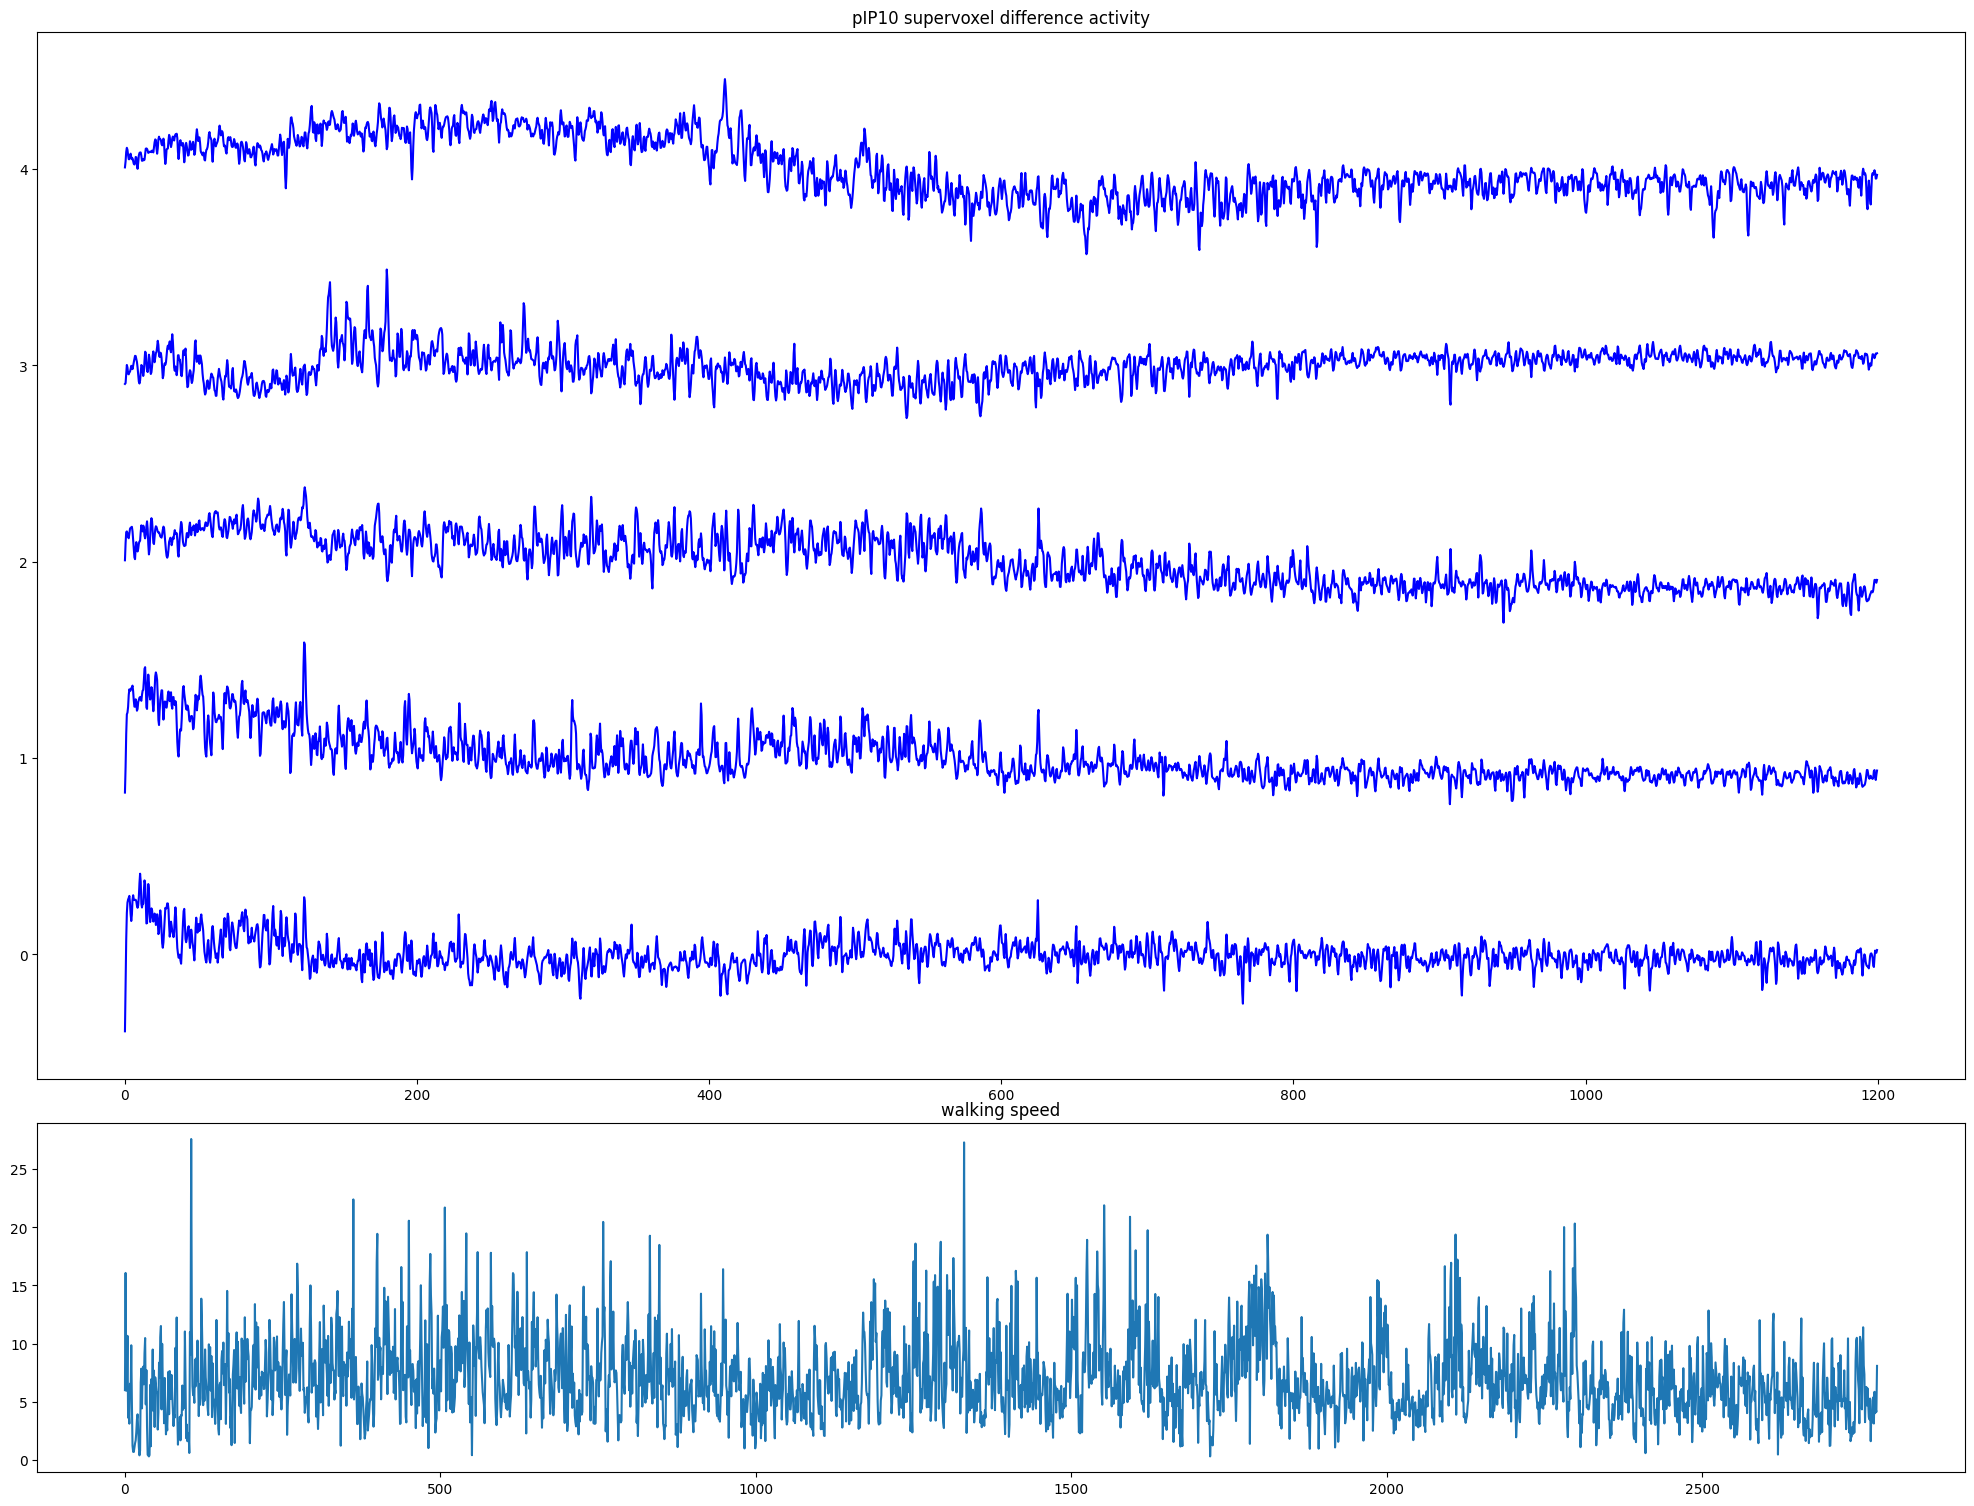

In [273]:
# difference between true and shifted supervoxels
diff_xr = signal_xr-sh_signal_xr
plot_zscored_activity(pip_rois, diff_xr, title = 'pIP10 supervoxel difference activity', yshift = 1)
#
trunc_diffs = diff_xr.isel(time=slice(0, DRIFT_INDEX))
trunc_behavior = behav_xr.isel(time=slice(0, DRIFT_INDEX))
# run correlation to walk
diff_correlation = xr.corr(trunc_diffs, trunc_behavior, dim='time')
for pip in pip_rois:
    to_plot = diff_correlation.isel(zposs=pip[0], roi=pip[1])
    print(f'{pip} correlation coefficient: {to_plot}')

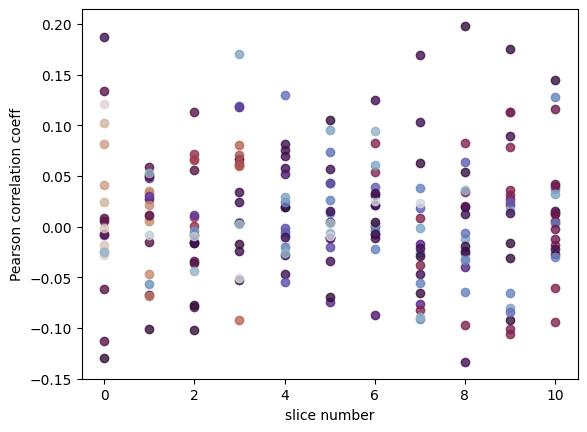

In [272]:
for iSlice in range(0 ,diff_xr['zposs'].max().item()+1):
    to_plot = correlation.isel(zposs=iSlice)
    for i, corrs in enumerate(to_plot):

        label = grouped_sv.supervoxel.sel(zposs=iSlice, roi=i).cluster.item()
        color = palette_colors[label-1]
        plt.scatter(iSlice, corrs, color=color, alpha=0.8)
        plt.xlabel('slice number')
        plt.ylabel('Pearson correlation coeff')


In [314]:
print(COOL_CLUSTER)

behav_xr

16


<xarray.DataArray (time: 2778)> Size: 22kB
array([ 6.00770995, 16.06981294,  5.95238239, ...,  4.37732605,
        4.13931998,  8.0854434 ], shape=(2778,))
Coordinates:
  * time     (time) float64 22kB 0.2327 0.6645 1.096 ... 1.199e+03 1.199e+03

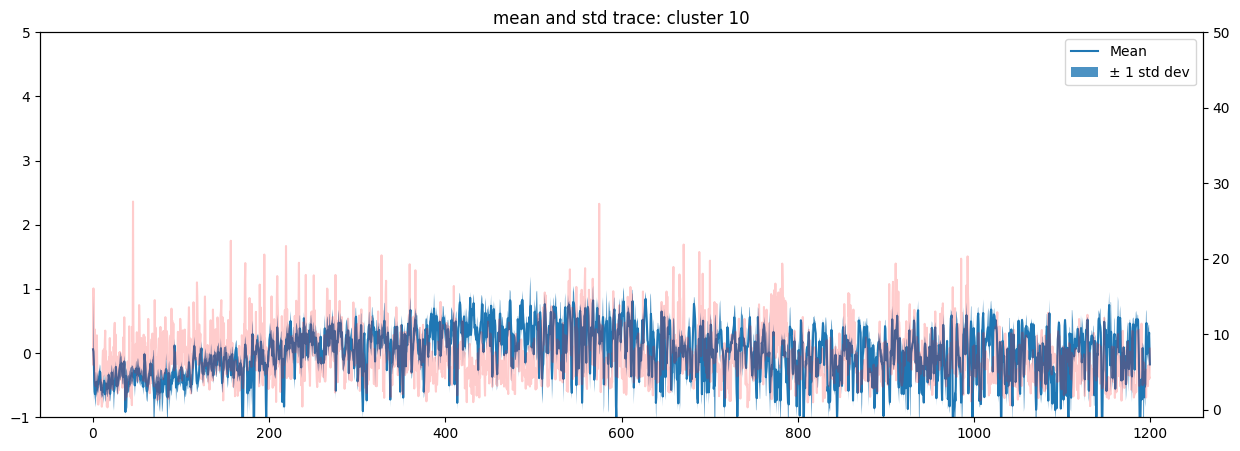

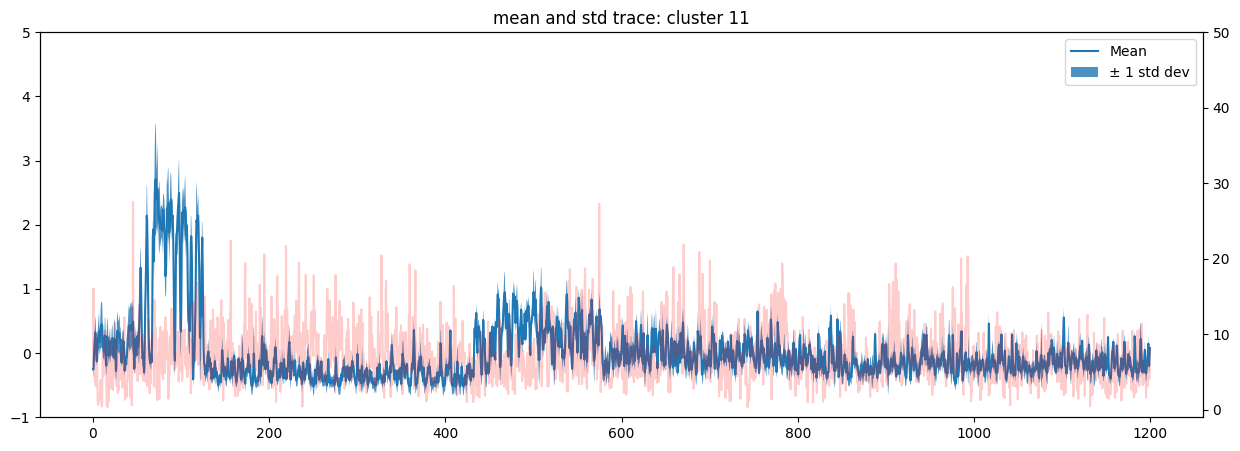

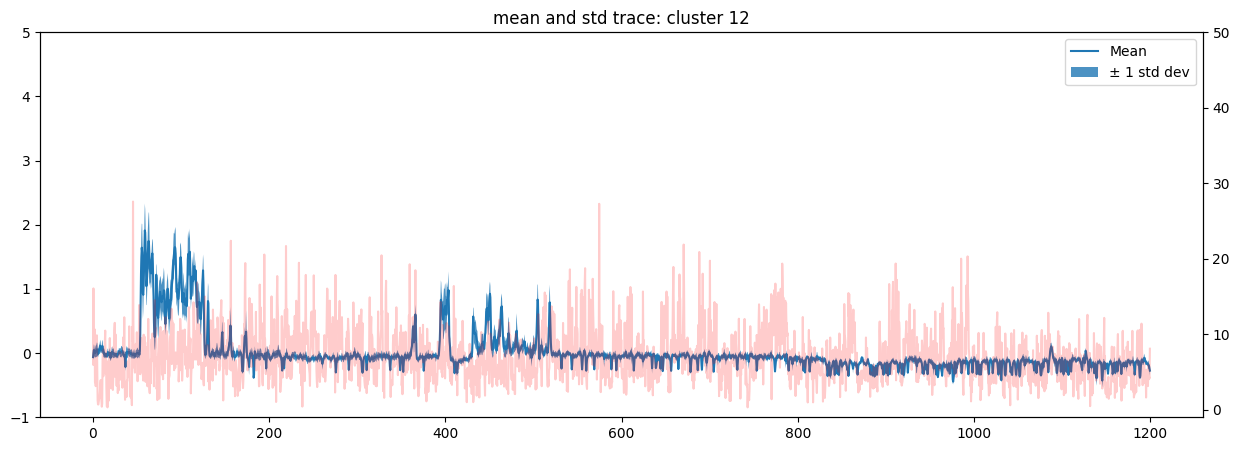

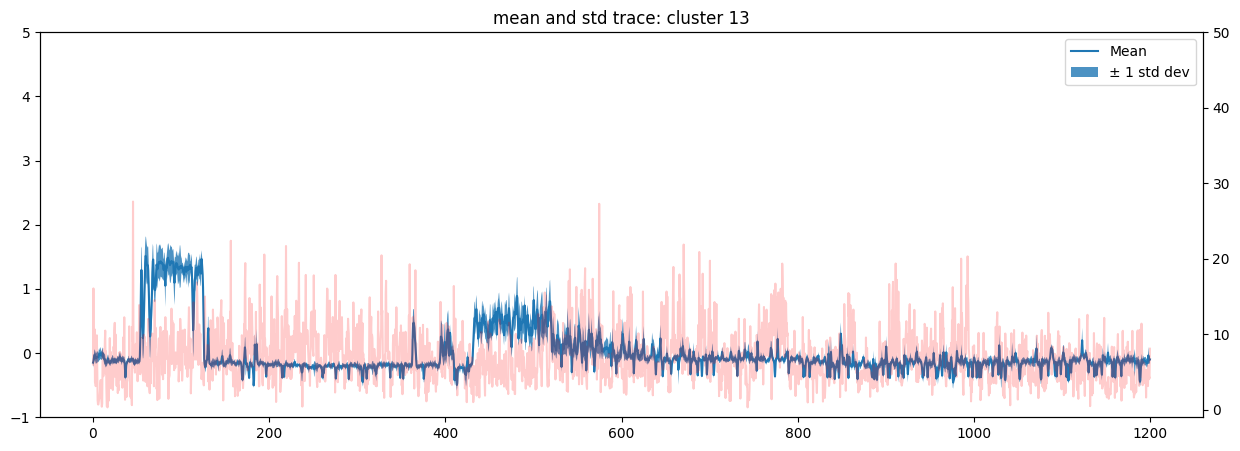

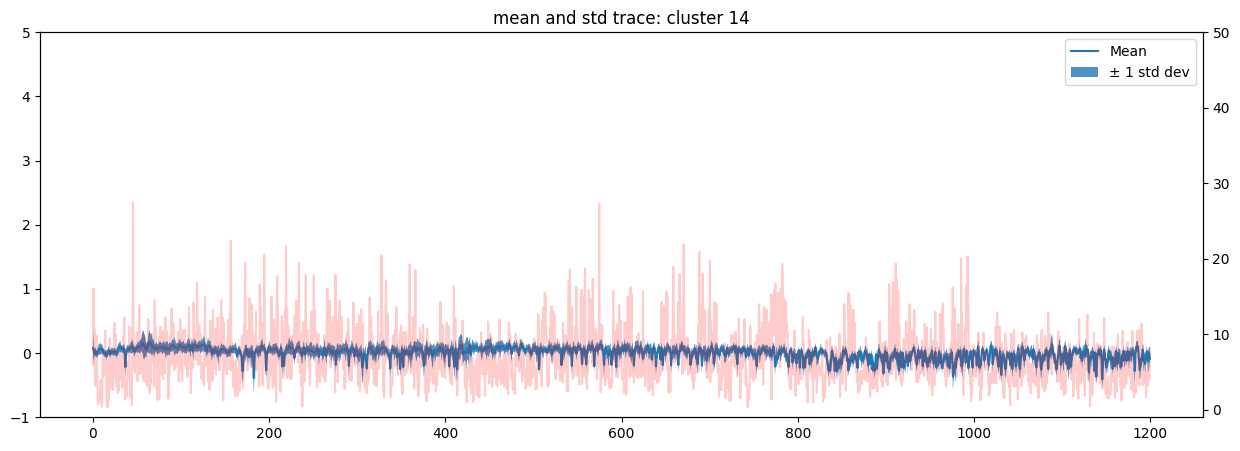

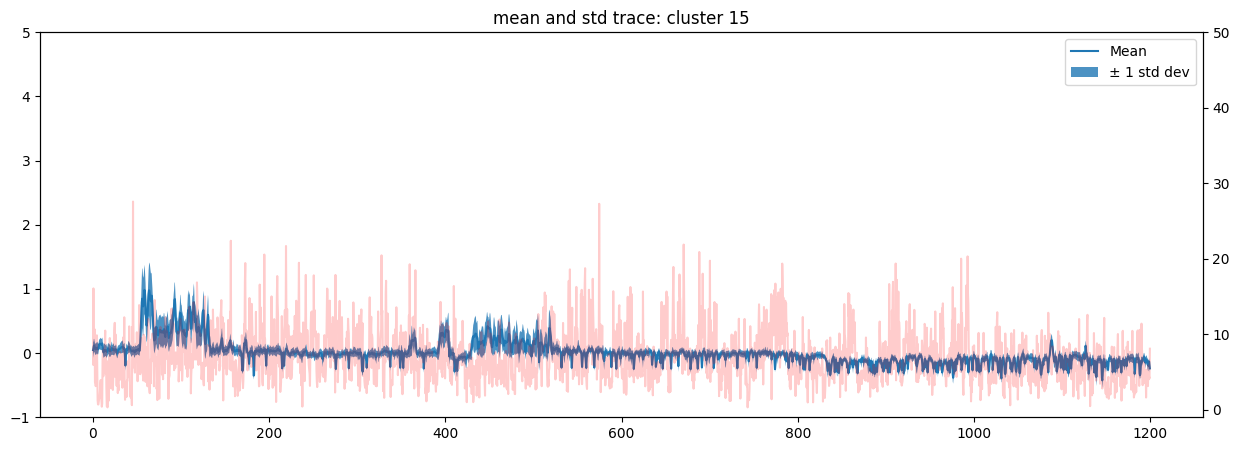

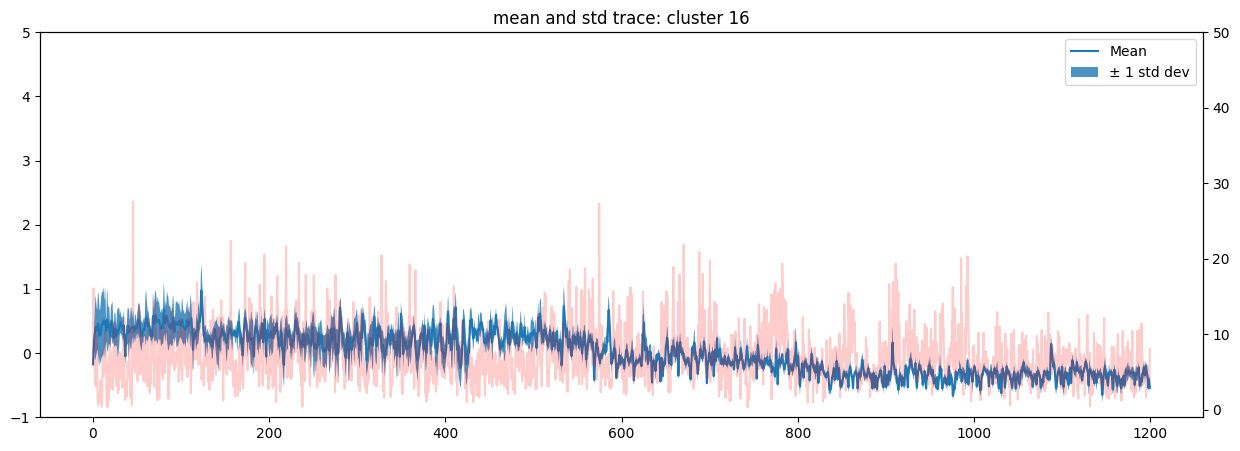

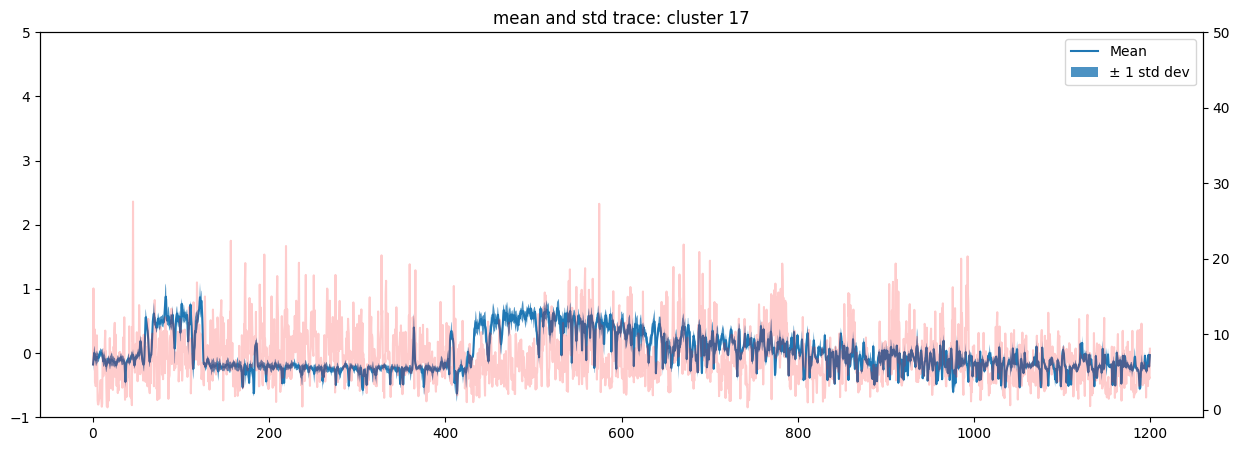

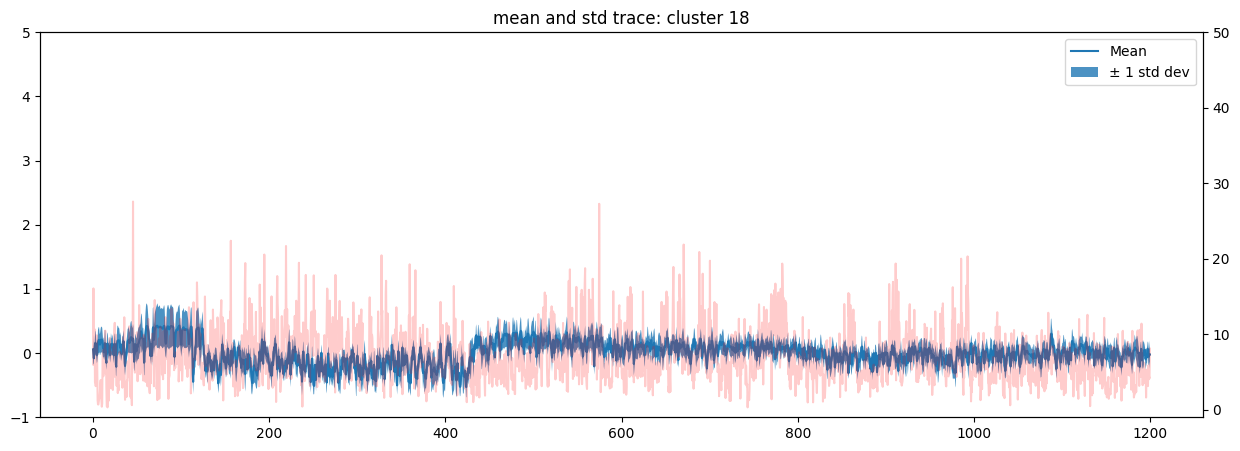

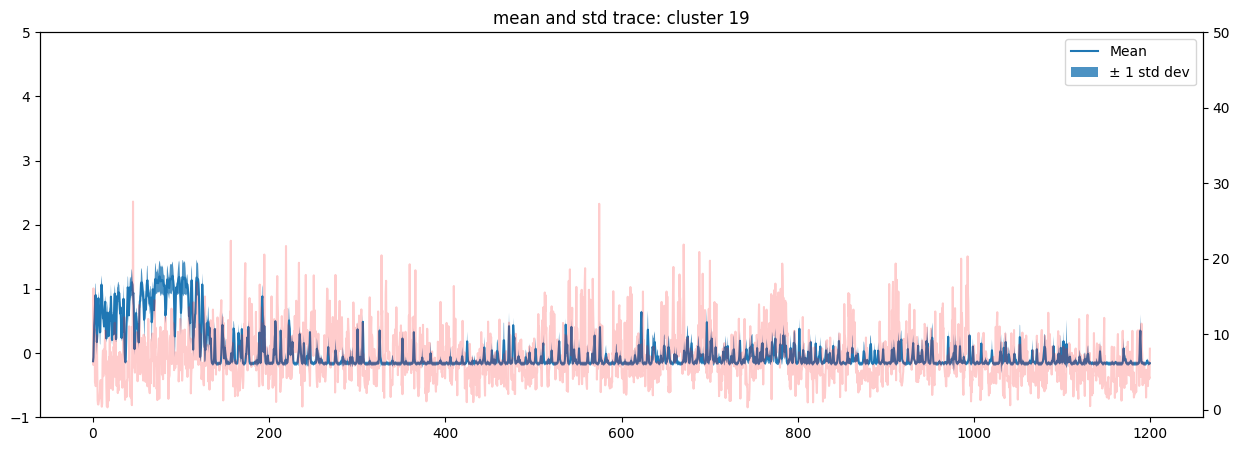

In [323]:
# mean cluster profile
for i in range(10, 20):
    cluster_xr = grouped_sv.sel(cluster=i)
    mean_trace = cluster_xr.mean(dim='supervoxel')
    std_trace = cluster_xr.std(dim='supervoxel')

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(mean_trace['time'], mean_trace.values, label='Mean')

    # Plot the shaded standard deviation area
    ax.fill_between(
        mean_trace['time'],
        (mean_trace - std_trace).values,
        (mean_trace + std_trace).values,
        alpha=0.8,
        label='± 1 std dev',
    )
    ax.legend()
    ax.set_title(f'mean and std trace: cluster {i}')
    ax.set_ylim(-1,5)
    ax2 = ax.twinx()
    ax2.plot(behav_xr['time'], behav_xr , label='walking speed', color='r', alpha=0.2)
    ax2.set_ylim(-1,50)